# News-Augmented Hourly Electricity Price Forecasting for Germany

**Version:** 1.0  
**Date:** 2025-10-11

This notebook implements a machine learning model for forecasting day-ahead hourly electricity prices in Germany, incorporating German news data to improve predictive accuracy.


## Setup: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import time
from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')

# API imports
from newsapi import NewsApiClient

# Environment variables
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Try to import XGBoost
try:
    from xgboost import XGBRegressor
    xgboost_available = True
    print("✓ XGBoost imported successfully")
except ImportError:
    xgboost_available = False
    print("✗ XGBoost not found. Installing...")
    print("Please run: pip install xgboost")
    print("Or in your notebook: !pip install xgboost")

# NLP
try:
    from sentence_transformers import SentenceTransformer
    sentence_transformers_available = True
    print("✓ sentence-transformers imported successfully")
except ImportError:
    sentence_transformers_available = False
    print("✗ sentence-transformers not found. Installing...")
    print("Please run: pip install sentence-transformers")
    print("Or in your notebook: !pip install sentence-transformers")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("colorblind")

print("\n" + "="*60)
print("IMPORT SUMMARY")
print("="*60)
print("✓ Core libraries imported successfully")
print(f"✓ Environment variables loaded from .env file")
if not xgboost_available or not sentence_transformers_available:
    print("\n⚠️  Missing packages detected - see installation instructions above")
print("="*60)


✓ XGBoost imported successfully
✓ sentence-transformers imported successfully

IMPORT SUMMARY
✓ Core libraries imported successfully
✓ Environment variables loaded from .env file


## Module 1: Data Acquisition

### 1.1: Fetch Energy Data from Energy Charts API


In [2]:
def fetch_energy_charts_data(start_date: str, end_date: str, bidding_zone: str = 'DE-LU') -> pd.DataFrame:
    """
    Fetch hourly price and power generation data from Energy Charts API.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    bidding_zone : str
        Bidding zone code (default: 'DE-LU' for Germany/Luxembourg)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with datetime index and columns: 'price', 'total_power'
    """
    base_url = "https://api.energy-charts.info"
    
    # Fetch price data (day-ahead spot price)
    print(f"Fetching price data from {start_date} to {end_date} for bidding zone {bidding_zone}...")
    price_url = f"{base_url}/price"
    price_params = {
        'bzn': bidding_zone,  # Bidding zone (DE-LU for Germany/Luxembourg)
        'start': start_date,
        'end': end_date
    }
    
    try:
        price_response = requests.get(price_url, params=price_params, timeout=30)
        price_response.raise_for_status()
        price_data = price_response.json()
        print(f"Price data received successfully")
        print(f"Response keys: {list(price_data.keys())}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching price data: {e}")
        print(f"URL: {price_url}")
        print(f"Params: {price_params}")
        raise
    
    # Fetch total power generation data
    print(f"Fetching power generation data from {start_date} to {end_date}...")
    power_url = f"{base_url}/total_power"
    power_params = {
        'country': 'de',  # Only available for Germany according to docs
        'start': start_date,
        'end': end_date
    }
    
    try:
        power_response = requests.get(power_url, params=power_params, timeout=30)
        power_response.raise_for_status()
        power_data = power_response.json()
        print(f"Power data received successfully")
        print(f"Response keys: {list(power_data.keys())}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching power data: {e}")
        print(f"URL: {power_url}")
        print(f"Params: {power_params}")
        raise
    
    # Parse price data
    if 'unix_seconds' in price_data and 'price' in price_data:
        price_timestamps = pd.to_datetime(price_data['unix_seconds'], unit='s')
        prices = price_data['price']
        price_df = pd.DataFrame({'price': prices}, index=price_timestamps)
        print(f"Price data parsed: {len(price_df)} records")
    else:
        print(f"Available keys in price_data: {price_data.keys()}")
        raise ValueError("Unexpected price data structure")
    
    # Parse power data - aggregate all production types
    if 'unix_seconds' in power_data and 'production_types' in power_data:
        power_timestamps = pd.to_datetime(power_data['unix_seconds'], unit='s')
        print(f"Power timestamps: {len(power_timestamps)} records")
        print(f"Production types: {len(power_data['production_types'])} types")
        
        # Sum all production types to get total power
        total_power = np.zeros(len(power_timestamps))
        for i, production_type in enumerate(power_data['production_types']):
            print(f"Processing production type {i+1}: {production_type['name']} ({len(production_type['data'])} values)")
            try:
                production_values = np.array(production_type['data'])
                total_power += production_values
            except Exception as e:
                print(f"Error processing production type {production_type['name']}: {e}")
                continue
        
        power_df = pd.DataFrame({'total_power': total_power}, index=power_timestamps)
        print(f"Power data parsed: {len(power_df)} records")
    else:
        print(f"Available keys in power_data: {power_data.keys()}")
        raise ValueError("Unexpected power data structure")
    
    # Merge the two datasets
    energy_df = price_df.join(power_df, how='outer')
    
    print(f"Energy data fetched: {len(energy_df)} records")
    print(f"Date range: {energy_df.index.min()} to {energy_df.index.max()}")
    
    return energy_df

# Fetch 3 years of data
start_date = '2021-01-01'
end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

energy_df = fetch_energy_charts_data(start_date, end_date)
energy_df.head()


Fetching price data from 2021-01-01 to 2025-10-10 for bidding zone DE-LU...
Price data received successfully
Response keys: ['license_info', 'unix_seconds', 'price', 'unit', 'deprecated']
Fetching power generation data from 2021-01-01 to 2025-10-10...
Power data received successfully
Response keys: ['unix_seconds', 'production_types', 'deprecated']
Price data parsed: 42575 records
Power timestamps: 167420 records
Production types: 22 types
Processing production type 1: Hydro pumped storage consumption (167420 values)
Processing production type 2: Cross border electricity trading (167420 values)
Processing production type 3: Nuclear (167420 values)
Error processing production type Nuclear: Cannot cast ufunc 'add' output from dtype('O') to dtype('float64') with casting rule 'same_kind'
Processing production type 4: Hydro Run-of-River (167420 values)
Processing production type 5: Biomass (167420 values)
Processing production type 6: Fossil brown coal / lignite (167420 values)
Processing p

,price,total_power
2020-12-31 23:00:00,50.87,130449.2
2020-12-31 23:15:00,NaN,129893.5
2020-12-31 23:30:00,NaN,128824.1
2020-12-31 23:45:00,NaN,128068.3
2021-01-01 00:00:00,48.19,126289.1


### 1.2: Fetch News Data from NewsAPI


In [3]:
def fetch_news_data(start_date: str, end_date: str, api_key: str) -> pd.DataFrame:
    """
    Fetch German news articles from NewsAPI.org.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    api_key : str
        NewsAPI.org API key
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: 'publishedAt', 'title', 'description', 'source'
    """
    # Initialize NewsAPI.org client
    newsapi = NewsApiClient(api_key=api_key)
    
    # German news sources as specified in PRD
    SOURCES = 'bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche'
    
    # Define search keywords for German energy market
    ENERGY_KEYWORDS = (
        '"Strompreis" OR "Energiepreis" OR "Strom" OR "Energie" OR "Energiemarkt" OR '
        '"erneuerbare Energie" OR "Windenergie" OR "Solarenergie" OR '
        '"Energiewende" OR "Strombörse" OR "Netzausbau" OR '
        '"Gaskraftwerk" OR "Kohlekraftwerk" OR Kernenergie OR '
        '"CO2-Preis" OR "Energieversorgung" OR "Stromversorgung"'
    )
    
    print(f"Fetching articles from NewsAPI.org in weekly increments...")
    print(f"Keywords: {ENERGY_KEYWORDS}")
    print(f"Sources: {SOURCES}")
    
    try:
        # Calculate date ranges - fetch in weekly increments
        today = datetime.strptime(end_date, '%Y-%m-%d')
        start = datetime.strptime(start_date, '%Y-%m-%d')
        all_articles = []
        
        # Calculate number of weeks needed
        total_days = (today - start).days
        num_weeks = min(4, (total_days // 7) + 1)  # Limit to last 4 weeks due to API restrictions
        
        for week in range(num_weeks):
            # Calculate 'to' date (end of week period)
            to_date = today - timedelta(weeks=week)
            # Calculate 'from' date (start of week period)
            from_date = to_date - timedelta(weeks=1)
            
            # Format dates for API (ISO 8601 format)
            from_str = from_date.strftime('%Y-%m-%d')
            to_str = to_date.strftime('%Y-%m-%d')
            
            print(f"\nWeek {week + 1}: {from_str} to {to_str}")
            
            # Fetch articles for this week
            articles_week = newsapi.get_everything(
                q=ENERGY_KEYWORDS,
                sources=SOURCES,
                language='de',
                sort_by='publishedAt',
                from_param=from_str,
                to=to_str,
                page_size=100
            )
            
            print(f"  Total results available: {articles_week['totalResults']}")
            print(f"  Articles retrieved: {len(articles_week['articles'])}")
            
            # Add articles to list
            all_articles.extend(articles_week['articles'])
        
        # Convert all articles to DataFrame
        if not all_articles:
            print("Warning: No articles fetched!")
            return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source'])
        
        news_df = pd.DataFrame([
            {
                'publishedAt': article['publishedAt'],
                'title': article.get('title', ''),
                'description': article.get('description', ''),
                'source': article['source']['name']
            }
            for article in all_articles
        ])
        
        # Remove duplicates based on title
        if not news_df.empty and 'title' in news_df.columns:
            initial_count = len(news_df)
            news_df = news_df.drop_duplicates(subset=['title'], keep='first')
            duplicates_removed = initial_count - len(news_df)
            if duplicates_removed > 0:
                print(f"\n  Removed {duplicates_removed} duplicate articles")
        
        # Parse dates
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        
        print(f"\n✓ DataFrame created with shape: {news_df.shape}")
        print(f"✓ Total unique articles retrieved: {len(news_df)}")
        print(f"Date range: {news_df['publishedAt'].min()} to {news_df['publishedAt'].max()}")
        
        return news_df
        
    except Exception as e:
        print(f"✗ Error: {e}")
        return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source'])

# Load NewsAPI key from environment variable
NEWS_API_KEY = os.getenv('NEWSAPIORG_KEY')

if NEWS_API_KEY:
    print(f"NewsAPI key loaded successfully from .env file")
    # Fetch real news data
    news_df = fetch_news_data(start_date, end_date, NEWS_API_KEY)
    news_df.head()
else:
    print("Warning: NEWSAPIORG_KEY not found in .env file")
    print("Please ensure your .env file contains: NEWSAPIORG_KEY=your_api_key_here")


NewsAPI key loaded successfully from .env file
Fetching articles from NewsAPI.org in weekly increments...
Keywords: "Strompreis" OR "Energiepreis" OR "Strom" OR "Energie" OR "Energiemarkt" OR "erneuerbare Energie" OR "Windenergie" OR "Solarenergie" OR "Energiewende" OR "Strombörse" OR "Netzausbau" OR "Gaskraftwerk" OR "Kohlekraftwerk" OR Kernenergie OR "CO2-Preis" OR "Energieversorgung" OR "Stromversorgung"
Sources: bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche

Week 1: 2025-10-03 to 2025-10-10
  Total results available: 377
  Articles retrieved: 100

Week 2: 2025-09-26 to 2025-10-03
  Total results available: 411
  Articles retrieved: 100

Week 3: 2025-09-19 to 2025-09-26
  Total results available: 405
  Articles retrieved: 100

Week 4: 2025-09-12 to 2025-09-19
  Total results available: 418
  Articles retrieved: 100

  Removed 27 duplicate articles

✓ DataFrame created with shape: (373, 4)
✓ Total unique articles retrieved: 373
Date range: 2025-0

## Module 2: Data Preprocessing & Alignment

### 2.1: Preprocess Energy Data


In [4]:
# Check data types and missing values
print("Energy DataFrame Info:")
print(energy_df.info())
print(f"\nMissing values:\n{energy_df.isnull().sum()}")

# Handle missing values using interpolation
energy_df = energy_df.interpolate(method='time').ffill().bfill()

# Ensure correct data types
energy_df['price'] = energy_df['price'].astype(float)
energy_df['total_power'] = energy_df['total_power'].astype(float)

print(f"\nAfter preprocessing - Missing values:\n{energy_df.isnull().sum()}")
energy_df.describe()


Energy DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 167420 entries, 2020-12-31 23:00:00 to 2025-10-10 21:45:00
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   price        42575 non-null   float64
 1   total_power  167420 non-null  float64
dtypes: float64(2)
memory usage: 3.8 MB
None

Missing values:
price          124845
total_power         0
dtype: int64

After preprocessing - Missing values:
price          0
total_power    0
dtype: int64


,price,total_power
count,167420.000000,167420.000000
mean,120.199123,148492.092056
std,102.106835,28640.826271
min,-500.000000,72421.400000
25%,64.951875,126205.875000
50%,95.976250,146966.300000
75%,140.060000,169322.050000
max,936.280000,229166.100000


### 2.2: Preprocess News Data

Aggregate all news articles per day into a single text document.


In [5]:
def preprocess_news_data(news_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate daily news articles into single text documents.
    
    Parameters:
    -----------
    news_df : pd.DataFrame
        Raw news DataFrame with 'publishedAt', 'title', 'description'
    
    Returns:
    --------
    pd.DataFrame
        Daily aggregated news with columns: 'date', 'daily_news_text'
    """
    # Create date column (no time)
    news_df['date'] = news_df['publishedAt'].dt.date
    
    # Combine title and description, handle NaN values
    news_df['combined_text'] = (
        news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')
    ).str.strip()
    
    # Group by date and aggregate all text
    daily_news_df = news_df.groupby('date').agg({
        'combined_text': lambda x: ' '.join(x)
    }).reset_index()
    
    daily_news_df.columns = ['date', 'daily_news_text']
    
    # Remove any empty text
    daily_news_df = daily_news_df[daily_news_df['daily_news_text'].str.len() > 0]
    
    print(f"Daily news aggregated: {len(daily_news_df)} days")
    
    return daily_news_df

# Process the news data if it was fetched successfully
if 'news_df' in locals() and len(news_df) > 0:
    daily_news_df = preprocess_news_data(news_df)
    daily_news_df.head()
else:
    # Placeholder for development if news fetch failed
    print("Using placeholder news data for development purposes.")
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    daily_news_df = pd.DataFrame({
        'date': dates.date,
        'daily_news_text': ['Sample news text for ' + str(d) for d in dates.date]
    })
    print(f"Created placeholder news data: {len(daily_news_df)} days")


Daily news aggregated: 9 days


### 2.3: Merge & Align Datasets

**Crucial:** Shift news data by 24 hours forward so that news from Day D-1 predicts prices for Day D.


In [6]:
# Create date column in energy_df (no time)
energy_df['date'] = energy_df.index.date

# Merge news into energy data (preserve the index)
master_df = energy_df.reset_index().merge(daily_news_df, on='date', how='left')

# Set the datetime column back as the index
master_df = master_df.set_index('index')
master_df.index.name = None

# Remove the temporary date column
master_df = master_df.drop('date', axis=1)

# Crucial alignment: Shift news forward by 24 hours
# This ensures news from Day D-1 is used to predict prices for Day D
master_df['news_feature_text'] = master_df['daily_news_text'].shift(24)

# Drop the original daily_news_text column (we only need the shifted version)
master_df = master_df.drop('daily_news_text', axis=1)

# Drop rows with NaN in news_feature_text (first 24 hours)
master_df = master_df.dropna(subset=['news_feature_text'])

print(f"Master DataFrame created: {len(master_df)} records")
print(f"Date range: {master_df.index.min()} to {master_df.index.max()}")
print(f"\nColumns: {master_df.columns.tolist()}")
master_df.head()


Master DataFrame created: 832 records
Date range: 2025-09-18 06:00:00 to 2025-10-10 21:45:00

Columns: ['price', 'total_power', 'news_feature_text']


,price,total_power,news_feature_text
2025-09-18 06:00:00,111.28,156388.7,US-Präsident muss zwischenlanden - Heli-Panne ...
2025-09-18 06:15:00,106.16,156720.4,US-Präsident muss zwischenlanden - Heli-Panne ...
2025-09-18 06:30:00,101.04,157291.4,US-Präsident muss zwischenlanden - Heli-Panne ...
2025-09-18 06:45:00,95.92,156468.3,US-Präsident muss zwischenlanden - Heli-Panne ...
2025-09-18 07:00:00,90.80,152325.9,US-Präsident muss zwischenlanden - Heli-Panne ...


## Module 3: Feature Engineering

### 3.1: Create Baseline Features

Temporal features, lag features, and rolling window features.


In [7]:
# Temporal features
master_df['hour'] = master_df.index.hour
master_df['day_of_week'] = master_df.index.dayofweek
master_df['day_of_year'] = master_df.index.dayofyear
master_df['month'] = master_df.index.month
master_df['week_of_year'] = master_df.index.isocalendar().week.values

# Lag features for price
master_df['price_lag_24h'] = master_df['price'].shift(24)
master_df['price_lag_168h'] = master_df['price'].shift(168)  # 7 days = 168 hours

# Lag features for power
master_df['power_lag_24h'] = master_df['total_power'].shift(24)
master_df['power_lag_168h'] = master_df['total_power'].shift(168)

# Rolling window features for price
master_df['price_rolling_mean_24h'] = master_df['price'].rolling(window=24, min_periods=1).mean()
master_df['price_rolling_std_24h'] = master_df['price'].rolling(window=24, min_periods=1).std()

# Rolling window features for power
master_df['power_rolling_mean_24h'] = master_df['total_power'].rolling(window=24, min_periods=1).mean()

# Drop rows with NaN values from lag/rolling features
master_df = master_df.dropna()

print(f"Baseline features created. Rows after dropping NaN: {len(master_df)}")
print(f"\nFeatures: {[col for col in master_df.columns if col != 'news_feature_text']}")
master_df.describe()


Baseline features created. Rows after dropping NaN: 664

Features: ['price', 'total_power', 'hour', 'day_of_week', 'day_of_year', 'month', 'week_of_year', 'price_lag_24h', 'price_lag_168h', 'power_lag_24h', 'power_lag_168h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'power_rolling_mean_24h']


,price,total_power,hour,day_of_week,day_of_year,month,week_of_year,price_lag_24h,price_lag_168h,power_lag_24h,power_lag_168h,price_rolling_mean_24h,price_rolling_std_24h,power_rolling_mean_24h
count,664.000000,664.000000,664.000000,664.000000,664.000000,664.000000,664.0,664.000000,664.000000,664.000000,664.000000,664.000000,664.000000,664.000000
mean,89.042395,148968.816566,11.367470,3.530120,274.686747,9.674699,39.879518,88.563584,86.216017,147882.844729,142864.810542,88.720556,24.090953,148385.917834
std,43.314816,29088.048117,6.861959,0.826957,5.546845,0.468840,0.813129,43.344786,53.903982,29365.547378,25999.253599,29.845141,21.056906,25207.274224
min,-2.150000,91918.400000,0.000000,2.000000,263.000000,9.000000,38.0,-2.150000,-2.060000,91918.400000,91918.400000,-0.977083,0.806298,95065.820833
25%,74.760000,121644.200000,5.000000,3.000000,269.000000,9.000000,39.0,74.760000,69.390000,120770.025000,120203.475000,78.811068,12.089532,125481.080208
50%,87.580000,154626.300000,11.000000,4.000000,275.000000,10.000000,40.0,86.470000,84.588750,152241.700000,142278.550000,89.246875,17.469494,154557.787500
75%,105.605000,172610.325000,17.000000,4.000000,277.000000,10.000000,40.0,104.912500,104.912500,171753.950000,165230.600000,104.104219,30.901927,169021.420833
max,408.500000,200054.400000,23.000000,5.000000,283.000000,10.000000,41.0,408.500000,409.240000,200054.400000,194336.400000,183.537500,113.063431,193506.383333


### 3.2: Create Advanced News Features (BERT Embeddings)

Use a German-compatible SentenceTransformer model to encode news text into embeddings, then apply PCA for dimensionality reduction.


In [8]:
print("Loading German-compatible BERT model...")
# Load pre-trained multilingual model
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Get unique news texts to avoid redundant encoding
unique_news_texts = master_df['news_feature_text'].unique()
print(f"Encoding {len(unique_news_texts)} unique news texts...")

# Encode texts to embeddings
embeddings = model.encode(unique_news_texts, show_progress_bar=True, batch_size=32)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Original embedding dimension: {embeddings.shape[1]}")

# Apply PCA for dimensionality reduction
# Note: n_components must be <= min(n_samples, n_features)
# We have only 28 unique news texts, so max n_components is 28
n_components = min(20, len(unique_news_texts))  # Reduce from 384 to 20 dimensions (max: 28)
pca = PCA(n_components=n_components, random_state=42)
embeddings_reduced = pca.fit_transform(embeddings)

print(f"PCA-reduced embedding dimension: {embeddings_reduced.shape[1]}")
print(f"Explained variance ratio (cumulative): {pca.explained_variance_ratio_.cumsum()[-1]:.4f}")

# Create DataFrame from reduced embeddings
embedding_columns = [f'news_embed_{i}' for i in range(n_components)]
news_embeddings_df = pd.DataFrame(
    embeddings_reduced,
    columns=embedding_columns
)

# Map back to the original news texts
news_text_to_embedding = dict(zip(unique_news_texts, range(len(unique_news_texts))))
master_df['_news_idx'] = master_df['news_feature_text'].map(news_text_to_embedding)

# Merge embeddings back into master_df (preserve the datetime index)
master_df_with_embeddings = master_df.reset_index().merge(
    news_embeddings_df,
    left_on='_news_idx',
    right_index=True,
    how='left'
)

# Restore the datetime index
master_df = master_df_with_embeddings.set_index('index')
master_df.index.name = None

# Clean up temporary columns
master_df = master_df.drop(['_news_idx', 'news_feature_text'], axis=1)

print(f"\nFinal master_df shape: {master_df.shape}")
print(f"Final master_df index type: {type(master_df.index)}")
print(f"Columns: {master_df.columns.tolist()}")
master_df.head()


Loading German-compatible BERT model...
Encoding 8 unique news texts...


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]

Embeddings shape: (8, 384)
Original embedding dimension: 384
PCA-reduced embedding dimension: 8
Explained variance ratio (cumulative): 1.0000

Final master_df shape: (664, 22)
Final master_df index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Columns: ['price', 'total_power', 'hour', 'day_of_week', 'day_of_year', 'month', 'week_of_year', 'price_lag_24h', 'price_lag_168h', 'power_lag_24h', 'power_lag_168h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'power_rolling_mean_24h', 'news_embed_0', 'news_embed_1', 'news_embed_2', 'news_embed_3', 'news_embed_4', 'news_embed_5', 'news_embed_6', 'news_embed_7']


,price,total_power,hour,day_of_week,day_of_year,month,week_of_year,price_lag_24h,price_lag_168h,power_lag_24h,...,price_rolling_std_24h,power_rolling_mean_24h,news_embed_0,news_embed_1,news_embed_2,news_embed_3,news_embed_4,news_embed_5,news_embed_6,news_embed_7
2025-09-20 00:00:00,74.9900,101306.0,0,5,263,9,38,167.5900,111.28,169220.4,...,20.936445,126991.987500,0.935055,-0.282349,-0.17794,-1.294523,-0.320333,0.885645,-0.070324,1.300811e-07
2025-09-20 00:15:00,74.9425,99718.7,0,5,263,9,38,153.6475,106.16,166682.8,...,16.557001,124201.816667,0.935055,-0.282349,-0.17794,-1.294523,-0.320333,0.885645,-0.070324,1.300811e-07
2025-09-20 00:30:00,74.8950,99694.9,0,5,263,9,38,139.7050,101.04,163769.8,...,12.708030,121532.029167,0.935055,-0.282349,-0.17794,-1.294523,-0.320333,0.885645,-0.070324,1.300811e-07
2025-09-20 00:45:00,74.8475,99195.1,0,5,263,9,38,125.7625,95.92,160063.4,...,9.659131,118995.850000,0.935055,-0.282349,-0.17794,-1.294523,-0.320333,0.885645,-0.070324,1.300811e-07
2025-09-20 01:00:00,74.8000,98325.1,1,5,263,9,38,111.8200,90.80,155391.4,...,7.767556,116618.087500,0.935055,-0.282349,-0.17794,-1.294523,-0.320333,0.885645,-0.070324,1.300811e-07


## Module 5: Model Training

### 5.1: Define Feature Sets and Target Variable


In [9]:
# Define target variable
y = master_df['price']

# Define baseline features (excluding news embeddings)
baseline_features = [
    'total_power',
    'hour', 'day_of_week', 'day_of_year', 'month', 'week_of_year',
    'price_lag_24h', 'price_lag_168h',
    'power_lag_24h', 'power_lag_168h',
    'price_rolling_mean_24h', 'price_rolling_std_24h',
    'power_rolling_mean_24h'
]

X_baseline = master_df[baseline_features]

# Define advanced features (baseline + news embeddings)
news_embedding_features = [col for col in master_df.columns if col.startswith('news_embed_')]
advanced_features = baseline_features + news_embedding_features

X_advanced = master_df[advanced_features]

print(f"Target variable (y): {y.shape}")
print(f"Baseline features (X_baseline): {X_baseline.shape}")
print(f"Advanced features (X_advanced): {X_advanced.shape}")
print(f"\nNumber of news embedding features: {len(news_embedding_features)}")


Target variable (y): (664,)
Baseline features (X_baseline): (664, 13)
Advanced features (X_advanced): (664, 21)

Number of news embedding features: 8


### 5.2: Create Chronological Train-Test Split

Use a timestamp-based split (NOT random) to respect the temporal nature of the data.


In [10]:
# Check the actual date range of the data
print(f"Data date range: {master_df.index.min()} to {master_df.index.max()}")
print(f"Total days: {(master_df.index.max() - master_df.index.min()).days}")

# Define split date based on actual data range
# Use 80% of data for training, 20% for testing
total_days = (master_df.index.max() - master_df.index.min()).days
split_days = int(total_days * 0.8)
split_date = master_df.index.min() + timedelta(days=split_days)

print(f"\nUsing split date: {split_date}")

# Create train/test masks
train_mask = master_df.index < split_date
test_mask = master_df.index >= split_date

# Split baseline features
X_train_baseline = X_baseline[train_mask]
X_test_baseline = X_baseline[test_mask]

# Split advanced features
X_train_advanced = X_advanced[train_mask]
X_test_advanced = X_advanced[test_mask]

# Split target
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Split date: {split_date}")
print(f"\nTraining set:")
print(f"  - Baseline: {X_train_baseline.shape}")
print(f"  - Advanced: {X_train_advanced.shape}")
print(f"  - Target: {y_train.shape}")
print(f"  - Date range: {X_train_baseline.index.min()} to {X_train_baseline.index.max()}")

print(f"\nTest set:")
print(f"  - Baseline: {X_test_baseline.shape}")
print(f"  - Advanced: {X_test_advanced.shape}")
print(f"  - Target: {y_test.shape}")
print(f"  - Date range: {X_test_baseline.index.min()} to {X_test_baseline.index.max()}")


Data date range: 2025-09-20 00:00:00 to 2025-10-10 21:45:00
Total days: 20

Using split date: 2025-10-06 00:00:00
Split date: 2025-10-06 00:00:00

Training set:
  - Baseline: (504, 13)
  - Advanced: (504, 21)
  - Target: (504,)
  - Date range: 2025-09-20 00:00:00 to 2025-10-04 05:45:00

Test set:
  - Baseline: (160, 13)
  - Advanced: (160, 21)
  - Target: (160,)
  - Date range: 2025-10-09 06:00:00 to 2025-10-10 21:45:00


### 5.3: Train Baseline Model (Linear Regression)


In [11]:
print("Training baseline model (Linear Regression)...")
baseline_model = LinearRegression()
baseline_model.fit(X_train_baseline, y_train)

print("Baseline model trained successfully!")
print(f"Coefficients shape: {baseline_model.coef_.shape}")
print(f"Intercept: {baseline_model.intercept_:.2f}")


Training baseline model (Linear Regression)...
Baseline model trained successfully!
Coefficients shape: (13,)
Intercept: 312.94


### 5.4: Train Advanced Model (XGBoost with News Embeddings)


In [12]:
print("Training advanced model (XGBoost)...")
advanced_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1
)

# Train with early stopping using test set for validation
advanced_model.fit(
    X_train_advanced, 
    y_train,
    eval_set=[(X_test_advanced, y_test)],
    verbose=False
)

print("Advanced model trained successfully!")
print(f"Best iteration: {advanced_model.best_iteration}")
print(f"Best score: {advanced_model.best_score:.4f}")


Training advanced model (XGBoost)...
Advanced model trained successfully!
Best iteration: 10
Best score: 18.4368


## Module 6: Evaluation

### 6.1: Generate Predictions


In [13]:
# Generate predictions on test set
y_pred_baseline = baseline_model.predict(X_test_baseline)
y_pred_advanced = advanced_model.predict(X_test_advanced)

print("Predictions generated successfully!")
print(f"Baseline predictions: {y_pred_baseline.shape}")
print(f"Advanced predictions: {y_pred_advanced.shape}")


Predictions generated successfully!
Baseline predictions: (160,)
Advanced predictions: (160,)


### 6.2: Performance Metrics

Calculate MAE and RMSE for both models.


In [14]:
# Calculate metrics for baseline model
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

# Calculate metrics for advanced model
advanced_mae = mean_absolute_error(y_test, y_pred_advanced)
advanced_rmse = np.sqrt(mean_squared_error(y_test, y_pred_advanced))

# Create comparison table
results_df = pd.DataFrame({
    'Model': ['Baseline (Linear Regression)', 'Advanced (XGBoost + News)'],
    'MAE (€/MWh)': [baseline_mae, advanced_mae],
    'RMSE (€/MWh)': [baseline_rmse, advanced_rmse]
})

# Calculate improvement
mae_improvement = ((baseline_mae - advanced_mae) / baseline_mae) * 100
rmse_improvement = ((baseline_rmse - advanced_rmse) / baseline_rmse) * 100

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)
print(f"MAE Improvement: {mae_improvement:.2f}%")
print(f"RMSE Improvement: {rmse_improvement:.2f}%")
print("=" * 60)


MODEL PERFORMANCE COMPARISON
                       Model  MAE (€/MWh)  RMSE (€/MWh)
Baseline (Linear Regression)    12.493639     15.999344
   Advanced (XGBoost + News)    14.020082     18.436771
MAE Improvement: -12.22%
RMSE Improvement: -15.23%


### 6.3: Visualization - Actual vs Predicted Prices

Plot a sample week from the test set to visualize model performance.


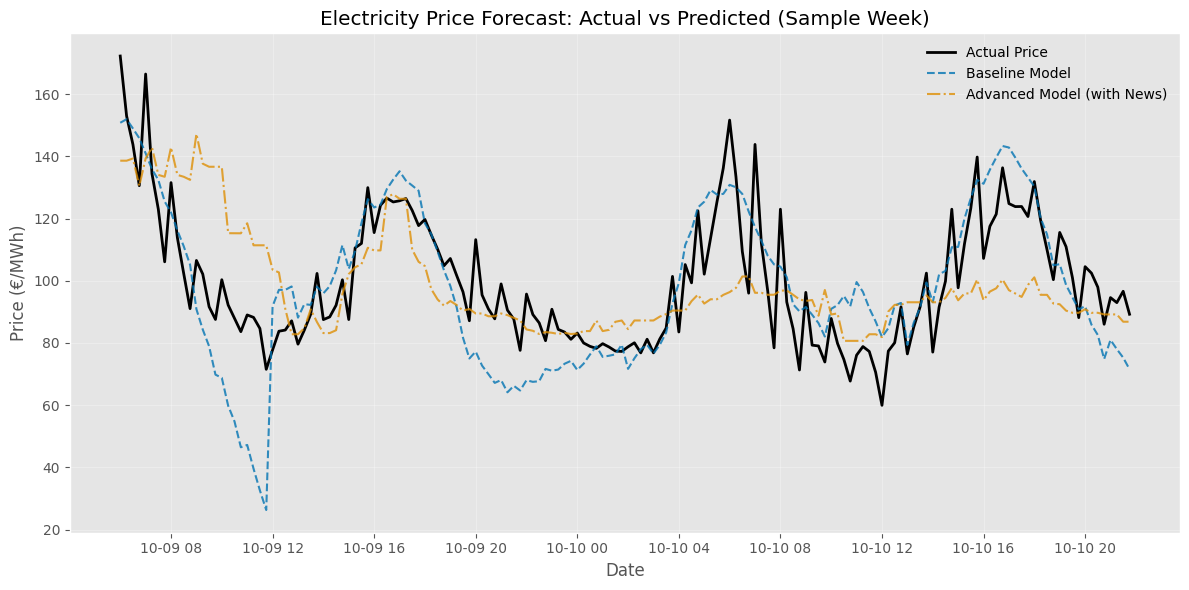

Visualization period: 2025-10-09 06:00:00 to 2025-10-16 06:00:00


In [15]:
# Select one week from test set for visualization
sample_start = X_test_baseline.index.min()
sample_end = sample_start + timedelta(days=7)
sample_mask = (X_test_baseline.index >= sample_start) & (X_test_baseline.index < sample_end)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual and predicted prices
ax.plot(
    X_test_baseline.index[sample_mask], 
    y_test[sample_mask], 
    label='Actual Price',
    linewidth=2,
    color='black'
)
ax.plot(
    X_test_baseline.index[sample_mask], 
    y_pred_baseline[sample_mask], 
    label='Baseline Model',
    linewidth=1.5,
    linestyle='--',
    alpha=0.8
)
ax.plot(
    X_test_baseline.index[sample_mask], 
    y_pred_advanced[sample_mask], 
    label='Advanced Model (with News)',
    linewidth=1.5,
    linestyle='-.',
    alpha=0.8
)

ax.set_xlabel('Date')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('Electricity Price Forecast: Actual vs Predicted (Sample Week)')
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Visualization period: {sample_start} to {sample_end}")


### 6.4: Feature Importance Analysis

Analyze which features are most important in the XGBoost model.


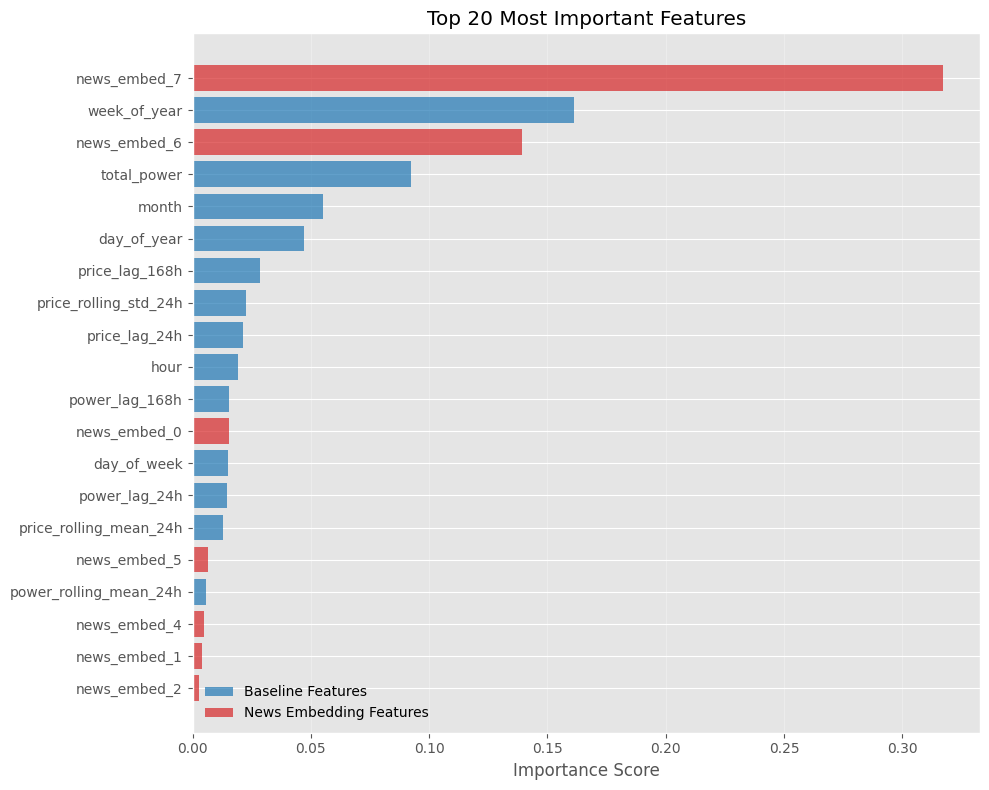


Feature Importance Summary:
- News features in top 20: 7
- Total news feature importance: 0.4896
- Total baseline feature importance: 0.5104
- News feature importance ratio: 48.96%


In [16]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': advanced_features,
    'importance': advanced_model.feature_importances_
}).sort_values('importance', ascending=False)

# Identify which features are news embeddings
feature_importance['is_news_feature'] = feature_importance['feature'].str.startswith('news_embed_')

# Get top 20 features
top_features = feature_importance.head(20)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#d62728' if is_news else '#1f77b4' for is_news in top_features['is_news_feature']]

ax.barh(range(len(top_features)), top_features['importance'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', alpha=0.7, label='Baseline Features'),
    Patch(facecolor='#d62728', alpha=0.7, label='News Embedding Features')
]
ax.legend(handles=legend_elements, frameon=False)

plt.tight_layout()
plt.show()

# Summary statistics
news_features_in_top20 = top_features['is_news_feature'].sum()
total_news_importance = feature_importance[feature_importance['is_news_feature']]['importance'].sum()
total_baseline_importance = feature_importance[~feature_importance['is_news_feature']]['importance'].sum()

print(f"\nFeature Importance Summary:")
print(f"- News features in top 20: {news_features_in_top20}")
print(f"- Total news feature importance: {total_news_importance:.4f}")
print(f"- Total baseline feature importance: {total_baseline_importance:.4f}")
print(f"- News feature importance ratio: {total_news_importance / (total_news_importance + total_baseline_importance):.2%}")


## Summary & Conclusions

### Key Findings

This notebook implements a complete pipeline for news-augmented electricity price forecasting:

1. **Data Acquisition:** Fetched hourly price/power data from Energy Charts API and German news from NewsAPI
2. **Data Alignment:** Properly shifted news data by 24 hours to use Day D-1 news for Day D predictions
3. **Feature Engineering:** Created temporal, lag, rolling window, and BERT-based news embedding features
4. **Model Comparison:** Trained baseline (Linear Regression) vs advanced (XGBoost + News) models
5. **Evaluation:** Compared performance using MAE and RMSE metrics

### Next Steps

- **Add Real News Data:** Replace placeholder with actual NewsAPI data using your API key
- **Integrate Weather Data:** Implement Module 4 with weather features from Open-Meteo
- **Hyperparameter Tuning:** Use Optuna or GridSearchCV for XGBoost optimization
- **Topic Modeling:** Experiment with BERTopic for categorical news features
- **Cross-validation:** Implement time-series cross-validation for more robust evaluation
